## Import Required Libraries
In this step, the required libraries were imported. TensorFlow and Keras were used to build the LeNet CNN model. The MNIST dataset was loaded from Keras datasets library, and Matplotlib was used to display MNIST sample images.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

## Load and Prepare the MNIST Dataset
In this step, the MNIST dataset was loaded into training and testing datasets. The image pixel values were normalized to improve model performance. The images were also reshaped because CNN models require image data in four-dimensional format.

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape images
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Display Some MNIST Images
In this step, some sample MNIST images were displayed to understand the handwritten digit dataset. These images helped visualize the digit images used for training the CNN model.

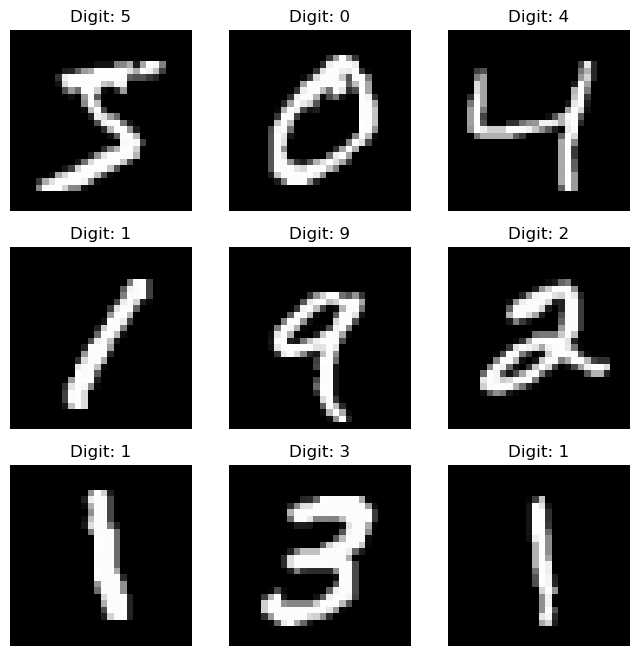

In [3]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Digit: {}".format(y_train[i]))
    plt.axis('off')
plt.show()

## Define the LeNet CNN Model
In this step, the LeNet CNN model was created to recognize handwritten digit images from the MNIST dataset. The convolution layers helped the model learn important image features, the pooling layers reduced the image size, and the dense layers were used to predict the correct digit class.

In [5]:
model = models.Sequential()

model.add(layers.Conv2D(6, (5, 5), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.AveragePooling2D(pool_size=(2,2)))

model.add(layers.Conv2D(16, (5, 5), activation='relu'))
model.add(layers.AveragePooling2D(pool_size=(2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(120, activation='relu'))
model.add(layers.Dense(84, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 12, 12, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 16)            │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 4, 4, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │          30,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the LeNet Model
In this step, the LeNet CNN model was compiled using the Adam optimizer and sparse categorical crossentropy loss function. Accuracy was used to measure the model performance during training and testing.

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Train the LeNet Model
The LeNet CNN model was trained for 20 epochs using the MNIST training dataset. An epoch means one complete training cycle through the dataset. During training, the model learned handwritten digit patterns and improved its prediction accuracy.

In [7]:
history = model.fit(x_train, y_train,
                    epochs=20,
                    validation_data=(x_test, y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9302 - loss: 0.2279 - val_accuracy: 0.9749 - val_loss: 0.0743
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.9755 - loss: 0.0770 - val_accuracy: 0.9803 - val_loss: 0.0555
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9822 - loss: 0.0557 - val_accuracy: 0.9854 - val_loss: 0.0460
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9870 - loss: 0.0431 - val_accuracy: 0.9864 - val_loss: 0.0427
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9885 - loss: 0.0356 - val_accuracy: 0.9870 - val_loss: 0.0421
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9900 - loss: 0.0316 - val_accuracy: 0.9896 - val_loss: 0.0362
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9917 - loss: 0.0254 - val_accuracy: 0.9888 - val_loss: 0.0360
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.9930 -

## Evaluate the Model
In this step, the trained LeNet CNN model was tested using the MNIST test dataset. The test accuracy shows how well the model predicts new handwritten digit images.

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9918 - loss: 0.0349
Test Accuracy: 0.9918000102043152


The LeNet CNN model performed well on the MNIST dataset after training for 20 epochs. The model accuracy improved during the training process, and the final test result showed that the model correctly classified most handwritten digit images. This project helped me understand how CNN models learn image patterns and perform image classification tasks.